## This file aims to check the accuracy of the OpenAsset Source file with the research 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
factors = pd.read_csv('../data-replication/factors_copy.csv', index_col=[0], header=[0])
open_ap_data = pd.read_csv('../data-replication/openap_monthly_factors.csv', index_col=[0], header=[0])
idx = factors.index
open_ap_data = open_ap_data.loc[idx, :]

open_ap_data.rename(columns={'zerotrade6M': 'zerotrade'}, inplace=True)

open_ap_data

,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,AdExp,AnalystRevision,AnalystValue,AnnouncementReturn,AssetGrowth,...,hire,realestate,retConglomerate,roaq,sinAlgo,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade
Date,,,,,,,,,,,,,,,,,,,,,
19760730,0.020440,-0.011267,0.002977,0.009063,0.024967,0.020870,0.005777,0.016280,0.015289,0.018687,...,0.014933,-0.001020,-0.000003,-0.019007,0.051008,0.034390,0.005802,0.048593,0.036163,0.042898
19760831,0.007702,0.033166,-0.002355,0.002400,0.016314,-0.000508,0.003921,-0.000290,0.016577,0.000119,...,-0.002270,-0.009796,0.013443,0.024297,-0.001190,0.018276,0.013372,0.037614,0.019027,0.040900
19760930,-0.009407,0.016639,0.001428,-0.004198,0.001640,-0.013090,0.015417,-0.000007,0.014850,-0.017851,...,-0.001174,-0.024878,0.024462,0.044787,0.008886,0.015195,0.007342,-0.015700,-0.001950,-0.026106
19761029,0.002840,0.001105,-0.003748,0.010869,-0.000268,-0.006461,0.003691,0.004504,0.011000,-0.007043,...,-0.006715,0.012778,0.063018,0.013265,-0.008071,0.022472,0.013046,0.017722,0.028582,0.024219
19761130,-0.017910,0.002581,0.005317,0.011683,-0.005830,-0.011509,-0.017864,0.038573,0.017073,-0.022828,...,-0.013807,0.035761,-0.006823,0.042044,-0.030567,-0.014746,-0.003330,-0.018743,-0.023570,-0.012592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20170831,-0.039652,0.000865,-0.013253,-0.016383,-0.013800,-0.016115,0.015971,-0.040245,0.012727,-0.017758,...,-0.033006,0.016515,0.026020,-0.007144,0.043559,0.027361,0.025555,0.031460,0.015000,0.038654
20170929,0.015232,-0.010696,-0.009086,-0.012334,0.043781,0.007779,-0.006535,-0.027900,-0.002195,0.036185,...,0.017956,-0.014534,-0.070784,-0.066376,-0.016850,-0.079689,0.041007,-0.057269,-0.035307,-0.058560
20171031,0.006872,-0.002047,-0.021958,-0.006605,-0.008588,-0.062074,0.014184,0.021771,0.025539,-0.018397,...,-0.004999,0.029166,-0.004490,0.072097,0.031159,0.014755,-0.004396,0.019318,0.016561,0.018832


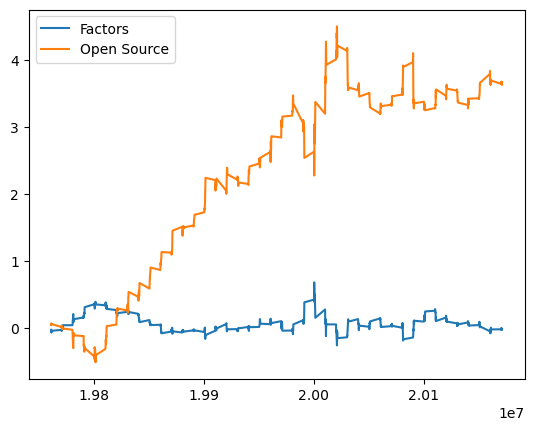

In [8]:
plt.plot(factors['maxret'].cumsum(), label='Factors')
plt.plot(open_ap_data['MaxRet'].cumsum(), label='Open Source')

plt.legend()
plt.show()

In [9]:
name2abbr = {
    "Beta": "beta",
    "EP": "ep",
    "DivYieldST": "dy",
    "LRreversal": "LTR",
    "Leverage": "lev",
    "BidAskSpread": "baspread",
    "Mom6m": "mom6m",
    "CF": "cp",
    "DivInit": "divi",
    "DivOmit": "divo",
    "Accruals": "acc",
    "SP": "sp",
    "GrSaleToGrInv": "pchsale_pchinvt",
    "OScore": "os",
    "ChInvIA": "pchcapx_ia",
    "IndMom": "indmom",
    "PS": "ps",
    "VolSD": "std_dolvol",
    "std_turn": "std_turn",
    "AdExp": "adm",
    "RD": "rdm",
    "ChInv": "chinv",
    "Illiquidity": "ill",
    "BetaLiquidityPS": "LIQ_PS",
    "GrLTNOA": "grltnoa",
    "OrderBacklog": "ob_a",
    "cfp": "cfp",
    "SurpriseRD": "rd",
    "Investment": "cinvest",
    "NOA": "noa",
    "dNoa": "dnoa",
    "Tax": "tb",
    "PriceDelaySlope": "pricedelay",
    "DelCOA": "dcoa",
    "DelCOL": "dcol",
    "DelNetFin": "dfin",
    "TotalAccruals": "ta",
    "MS": "ms",
    "grcapx": "grcapx",
    "CoskewACX": "retvol",
    "zerotrade": "zerotrade",
    "CompEqulss": "cei",
    "NetEquityFinance": "nef",
    "NetDebtFinance": "ndf",
    "XFIN": "nxf",
    "RevenueSurprice": "rs",
    "Herf": "herf",
    "PayoutYield": "op",
    "NetPayoutYield": "nop",
    "NetDebtPrice": "ndp",
    "EBM": "ebp",
    "Sharelss1Y": "chcsho",
    "AnnouncementReturn": "ear",
    "Mom12mOffSeason": "moms12m",
    "InvestPPEInv": "dpia",
    "CompositeDebtIssuance": "cdi",
    "ChNNCOA": "rna",
    "ChAssetTurnover": "chatoia",
    "CashProd": "cashpr",
    "sinAlgo": "sin",
    "roaq": "roaq",
    "realestate": "realestate_hxz",
    "PctAcc": "pctacc",
    "MaxRet": "maxret",
    "OPLeverage": "ol",
    "InvGrowth": "ivg",
    "EntMult": "em",
    "Cash": "cash",
    "GP": "gma",
    "OrgCap": "orgcap",
    "BetaFP": "BAB",
    "hire": "hire",
    "GrAdExp": "gad",
    "ConvDebt": "convind",
}

In [10]:
keep = [c for c in open_ap_data.columns if c in name2abbr]
df_mapped = open_ap_data.loc[:, keep].rename(columns=name2abbr)

ci = {k.lower(): v for k, v in name2abbr.items()}
keep_ci = [c for c in open_ap_data.columns if c.lower() in ci]
df_mapped_ci = open_ap_data.loc[:, keep_ci].rename(columns=lambda c: ci.get(c.lower(), c))
factors = factors[sorted(factors.columns)]

factors = factors[df_mapped_ci.columns]

In [11]:
def _align_frames(A: pd.DataFrame, B: pd.DataFrame, cols=None):
    common_idx = A.index.intersection(B.index)
    common_cols = A.columns.intersection(B.columns) if cols is None else pd.Index(cols).intersection(A.columns).intersection(B.columns)
    A1 = A.loc[common_idx, common_cols].sort_index()
    B1 = B.loc[common_idx, common_cols].sort_index()
    return A1, B1, list(common_cols)

def lin_ccc(x: pd.Series, y: pd.Series):
    df = pd.concat([x, y], axis=1).dropna()
    if df.shape[0] < 2:
        return np.nan
    x = df.iloc[:,0].values
    y = df.iloc[:,1].values
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sdx, sdy = np.sqrt(vx), np.sqrt(vy)
    r = np.corrcoef(x, y)[0,1] if sdx > 0 and sdy > 0 else np.nan
    denom = vx + vy + (mx - my)**2
    if denom == 0:
        return np.nan
    return 2 * r * sdx * sdy / denom

In [12]:
def compute_column_metrics(factors: pd.DataFrame,
                           df_mapped_ci: pd.DataFrame,
                           cols=None,
                           standardize=False,
                           eps=1e-12):
    A, B, used_cols = _align_frames(factors, df_mapped_ci, cols)
    rows = []
    for c in used_cols:
        pair = pd.concat([A[c], B[c]], axis=1, keys=['A','B']).dropna()
        n = len(pair)
        if n == 0:
            rows.append({
                'col': c, 'n': 0, 'pearson': np.nan, 'spearman': np.nan, 'r2': np.nan,
                'rmse': np.nan, 'mae': np.nan, 'mape': np.nan, 'bias_mean(A-B)': np.nan,
                'std_diff': np.nan, 'ccc': np.nan
            })
            continue

        x = pair['A'].to_numpy(dtype=float)
        y = pair['B'].to_numpy(dtype=float)

        if standardize:
            def zscore(v):
                v = v.copy()
                m, s = np.nanmean(v), np.nanstd(v, ddof=1)
                return (v - m) / (s if s > 0 else 1.0)
            x = zscore(x)
            y = zscore(y)

        err = x - y
        rmse = float(np.sqrt(np.mean(err**2)))
        mae  = float(np.mean(np.abs(err)))
        mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y), eps)))

        if np.std(x, ddof=1) > 0 and np.std(y, ddof=1) > 0:
            pearson = float(np.corrcoef(x, y)[0,1])
            spearman = float(pd.Series(x).corr(pd.Series(y), method='spearman'))
            r2 = float(pearson**2)
        else:
            pearson = spearman = r2 = np.nan

        ccc = float(lin_ccc(pd.Series(x), pd.Series(y)))

        rows.append({
            'col': c,
            'n': n,
            'pearson': pearson,
            'spearman': spearman,
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias_mean(A-B)': float(np.mean(err)),
            'std_diff': float(np.std(err, ddof=1)) if n > 1 else 0.0,
            'ccc': ccc,
        })
    out = pd.DataFrame(rows).set_index('col')
    return out.sort_values('rmse', na_position='last')

In [13]:
def plot_compare(factors: pd.DataFrame,
                 df_mapped_ci: pd.DataFrame,
                 col: str,
                 kind='timeseries',
                 standardize=False):
    """
    kind ∈ {'timeseries', 'scatter', 'diff'}
    """
    A, B, _ = _align_frames(factors, df_mapped_ci, cols=[col])
    pair = pd.concat([A[col], B[col]], axis=1, keys=['A','B']).dropna()
    if pair.empty:
        raise ValueError(f'No overlapping non-NaN data for column: {col}')

    x = pair['A'].copy()
    y = pair['B'].copy()

    if standardize:
        def zscore(s):
            m, sd = s.mean(), s.std(ddof=1)
            return (s - m) / (sd if sd > 0 else 1.0)
        x = zscore(x)
        y = zscore(y)

    if kind == 'timeseries':
        plt.figure()
        x.plot()
        y.plot()
        plt.title(f'{col} (A=factors, B=df_mapped_ci)')
        plt.legend(['A', 'B'])
        plt.xlabel('index')
        plt.ylabel(col)
        plt.show()

    elif kind == 'scatter':
        plt.figure()
        plt.scatter(x, y, s=10)
        lo = np.nanmin([x.min(), y.min()])
        hi = np.nanmax([x.max(), y.max()])
        plt.plot([lo, hi], [lo, hi])
        plt.title(f'{col}: A vs B (y=x line)')
        plt.xlabel('A (factors)')
        plt.ylabel('B (df_mapped_ci)')
        plt.show()

    elif kind == 'diff':
        plt.figure()
        (x - y).plot()
        plt.title(f'{col}: (A - B)')
        plt.xlabel('index')
        plt.ylabel('A - B')
        plt.show()

    else:
        raise ValueError("kind must be one of {'timeseries','scatter','diff'}")

In [14]:
def rank_columns(factors, df_mapped_ci, by='rmse', ascending=True, top=20, **kwargs):
    met = compute_column_metrics(factors, df_mapped_ci, **kwargs)
    return met.sort_values(by, ascending=ascending).head(top)

In [15]:
metrics = compute_column_metrics(factors, df_mapped_ci, standardize=False)
display(metrics)

,n,pearson,spearman,r2,rmse,mae,mape,bias_mean(A-B),std_diff,ccc
col,,,,,,,,,,
convind,498,0.685729,0.647093,0.470224,0.011934,0.008991,2.895980,-0.002462,0.011689,0.676115
chatoia,498,0.395766,0.375521,0.156631,0.012737,0.009660,5.008284,-0.000375,0.012745,0.393635
cdi,498,0.407180,0.385257,0.165796,0.012953,0.009656,7.512165,-0.002315,0.012757,0.392039
pchsale_pchinvt,498,0.287999,0.244531,0.082944,0.014924,0.011427,2.664274,-0.000970,0.014907,0.285605
dcol,498,0.678525,0.661889,0.460396,0.014982,0.011591,2.449013,-0.002711,0.014749,0.668981
...,...,...,...,...,...,...,...,...,...,...
mom6m,498,0.231622,0.249859,0.053649,0.071057,0.041296,2.875808,-0.006180,0.070859,0.146659
zerotrade,498,-0.657952,-0.720735,0.432901,0.075257,0.056715,3.145840,-0.005514,0.075130,-0.637129
std_turn,498,-0.519426,-0.582486,0.269804,0.084061,0.061210,2.198095,-0.004749,0.084012,-0.453113


In [19]:
metrics[metrics['pearson'] > 0.8]

,n,pearson,spearman,r2,rmse,mae,mape,bias_mean(A-B),std_diff,ccc
col,,,,,,,,,,
nef,498,0.807182,0.748214,0.651542,0.029637,0.021280,2.583287,-0.006405,0.028965,0.705065
cash,498,0.833640,0.715092,0.694956,0.031291,0.021240,2.174037,-0.004878,0.030939,0.713902
beta,498,0.890244,0.872162,0.792534,0.034658,0.023916,1.558103,-0.002308,0.034616,0.837899


In [16]:
worst = rank_columns(factors, df_mapped_ci, by='rmse', ascending=False, top=10)
print(worst)

             n   pearson  spearman        r2      rmse       mae      mape  \
col                                                                          
maxret     498 -0.782487 -0.700774  0.612286  0.107981  0.073083  2.488488   
BAB        498 -0.552295 -0.397900  0.305029  0.105297  0.073812  2.047875   
std_turn   498 -0.519426 -0.582486  0.269804  0.084061  0.061210  2.198095   
zerotrade  498 -0.657952 -0.720735  0.432901  0.075257  0.056715  3.145840   
mom6m      498  0.231622  0.249859  0.053649  0.071057  0.041296  2.875808   
roaq       498 -0.651457 -0.587357  0.424397  0.068246  0.048702  2.525193   
ps         498  0.308574  0.312737  0.095218  0.067941  0.045929  1.608602   
moms12m    498  0.511703  0.513504  0.261840  0.059459  0.038548  1.641067   
baspread   498  0.611032  0.538605  0.373360  0.057213  0.039265  3.341526   
adm        498 -0.553533 -0.605442  0.306399  0.055496  0.041561  2.935503   

           bias_mean(A-B)  std_diff       ccc  
col            

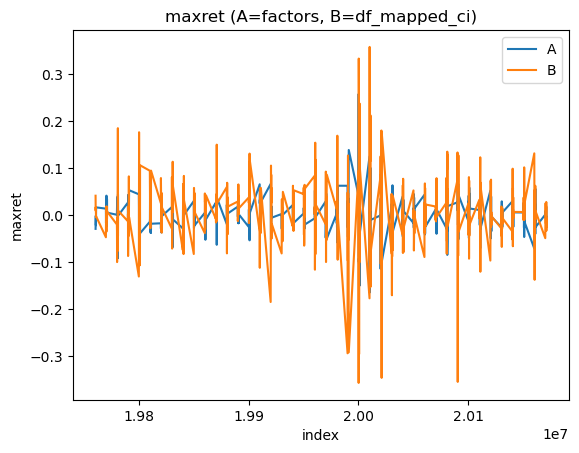

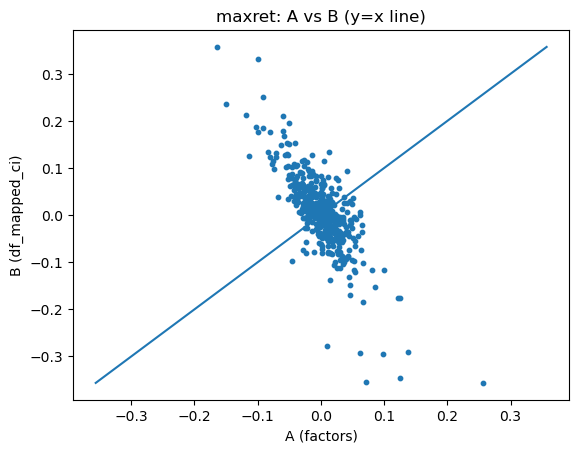

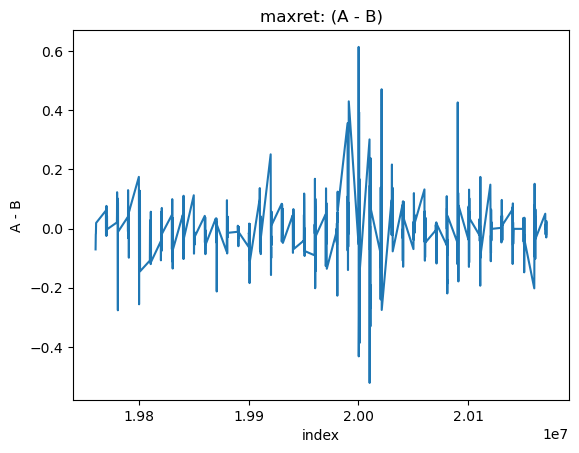

In [17]:
plot_compare(factors, df_mapped_ci, col='maxret', kind='timeseries')
plot_compare(factors, df_mapped_ci, col='maxret', kind='scatter')
plot_compare(factors, df_mapped_ci, col='maxret', kind='diff')